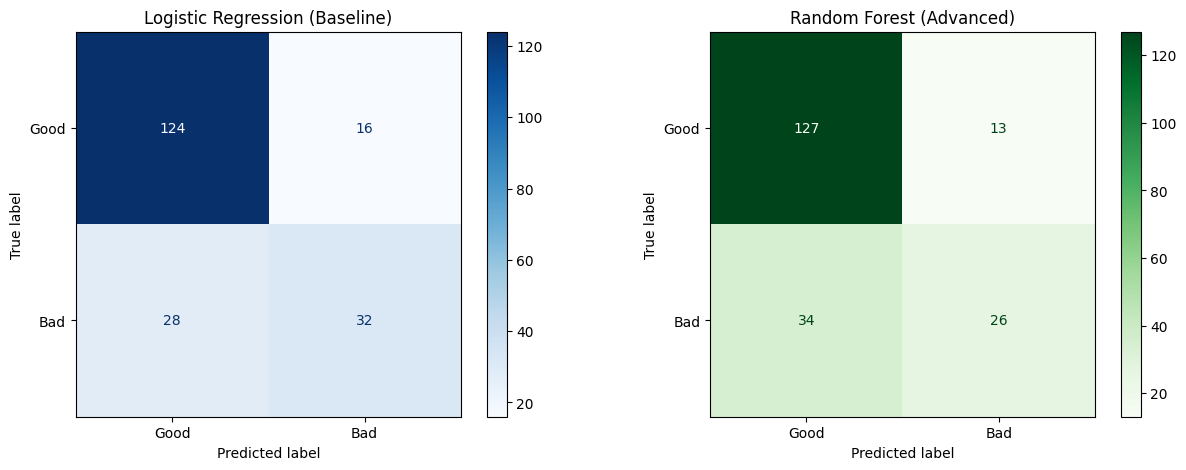

--- Random Forest Detailed Report ---
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       140
           1       0.67      0.43      0.53        60

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.68       200
weighted avg       0.75      0.77      0.75       200



In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Re-Load and Re-Scale (The "Recovery" Step)
df = pd.read_csv('../data/german_credit_mapped.csv')
X = pd.get_dummies(df.drop('class', axis=1), drop_first=False)
y = df['class'].map({'Good Risk': 0, 'Bad Risk': 1})

# Scale only the numeric ones to keep it "Viva-Ready"
cols_to_scale = ['duration', 'credit_amount', 'age', 'installment_commitment', 
                  'residence_since', 'existing_credits', 'num_dependents']
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Re-Train for Sprint 5 Evaluation
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# 3. Sprint 5 Visual: Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, display_labels=['Good', 'Bad'], cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression (Baseline)')

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=['Good', 'Bad'], cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest (Advanced)')
plt.show()

print("--- Random Forest Detailed Report ---")
print(classification_report(y_test, rf.predict(X_test)))